# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Muhammad Fasya Atthaya Rosyada| 5054251006|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('diabetes.csv')

print("Informasi Dataset")
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
print("\nTipe Data")
print(df.dtypes)
print("\nJumlah Missing Value (Null) Awal")
print(df.isnull().sum())
print("\nStatistik Deskriptif")
display(df.describe())

Informasi Dataset
Jumlah baris: 768, Jumlah kolom: 9

Tipe Data
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Jumlah Missing Value (Null) Awal
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Statistik Deskriptif


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


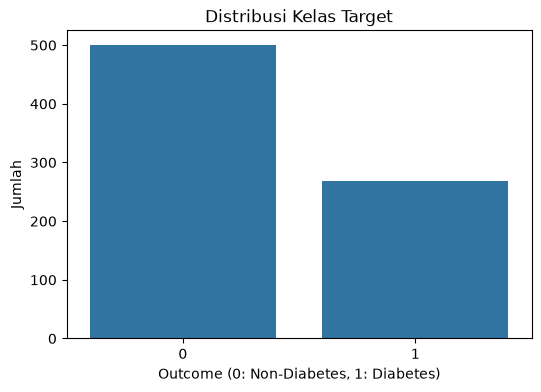

Persentase Non-Diabetes (0): 65.10%
Persentase Diabetes (1): 34.90%


In [3]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome')
plt.title('Distribusi Kelas Target')
plt.xlabel('Outcome (0: Non-Diabetes, 1: Diabetes)')
plt.ylabel('Jumlah')
plt.show()

rasio = df['Outcome'].value_counts(normalize=True) * 100
print(f"Persentase Non-Diabetes (0): {rasio[0]:.2f}%")
print(f"Persentase Diabetes (1): {rasio[1]:.2f}%")

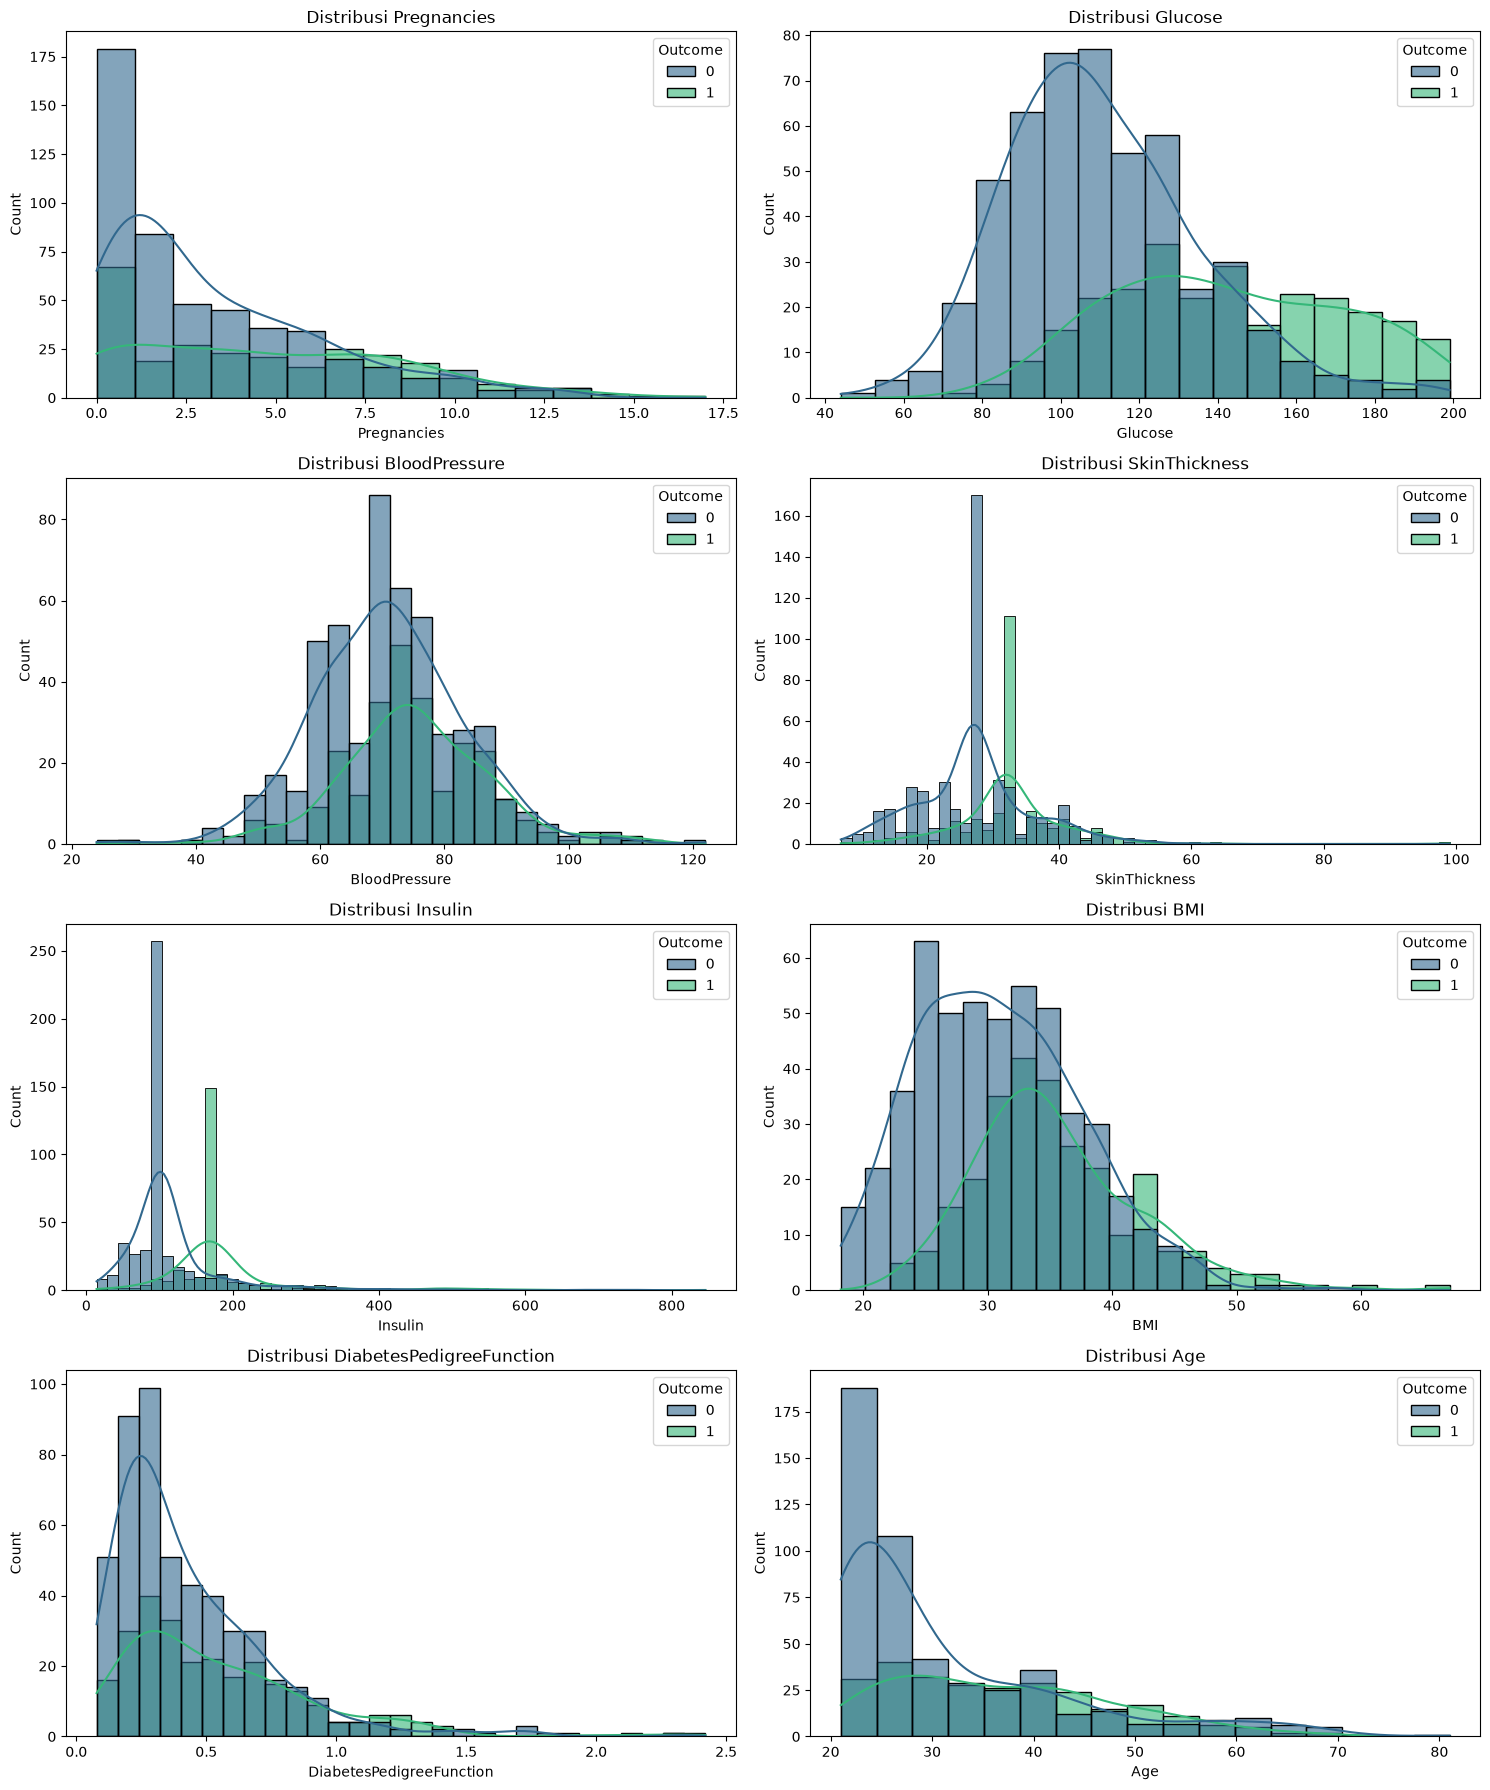

In [4]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, ax=axes[i], palette='viridis', alpha=0.6)
    axes[i].set_title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

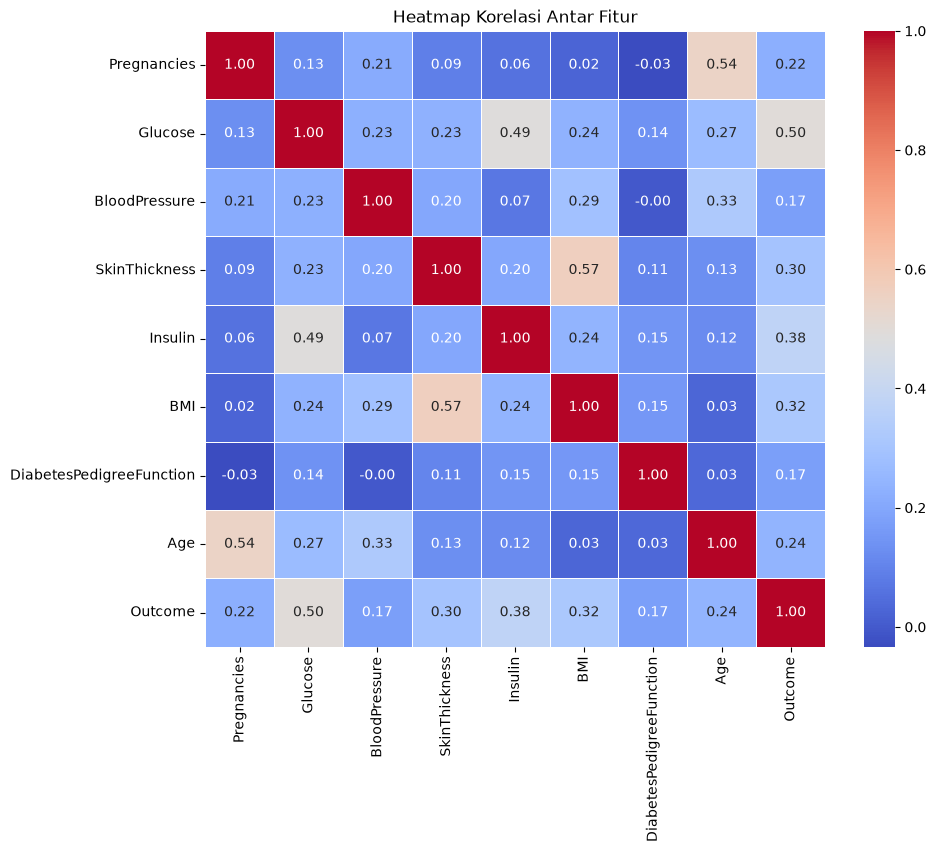

In [5]:
# Tampilkan heatmap korelasi antar fitur.
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [6]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
cols_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_counts = (df[cols_zero] == 0).sum()
print("Jumlah nilai 0 pada masing-masing kolom:")
print(zero_counts)

Jumlah nilai 0 pada masing-masing kolom:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [7]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
df[cols_zero] = df[cols_zero].replace(0, np.nan)

print("Jumlah NaN setelah konversi:")
print(df[cols_zero].isnull().sum())

Jumlah NaN setelah konversi:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [8]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
x = df.drop('Outcome', axis=1)
y = df['Outcome']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

for col in cols_zero:
    median_value = x_train[col].median()
    x_train[col].fillna(median_value)
    x_test[col].fillna(median_value)

print("Dimensi x_train:", x_train.shape)
print("Dimensi x_test:", x_test.shape)

Dimensi x_train: (614, 8)
Dimensi x_test: (154, 8)


In [9]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [10]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[400.,214.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.65,0.35]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[-0.15,-0.38,-0.14,...,-0.24,-0.12,-0.18], [ 0.28, 0.71, 0.26,..., 0.45, 0.23, 0.33]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[0.81,0.61,0.98,...,0.86,0.85,0.96], [1.23,0.97,0.94,...,0.94,1.2 ,0.91]]"


In [11]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
nb_preds = nb_model.predict(X_test_scaled)
nb_probs = nb_model.predict_proba(X_test_scaled)[:, 1]

## 3.2 Logistic Regression

In [12]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [13]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluasi Model

In [14]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
def print_metrics(y_true, y_pred, model_name):
    print(f"Metrik Evaluasi {model_name}")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_true, y_pred):.4f}\n")

print_metrics(y_test, nb_preds, "Gaussian Naive Bayes")
print_metrics(y_test, lr_preds, "Logistic Regression")

Metrik Evaluasi Gaussian Naive Bayes
Accuracy  : 0.7273
Precision : 0.6034
Recall    : 0.6481
F1-Score  : 0.6250

Metrik Evaluasi Logistic Regression
Accuracy  : 0.7078
Precision : 0.5882
Recall    : 0.5556
F1-Score  : 0.5714



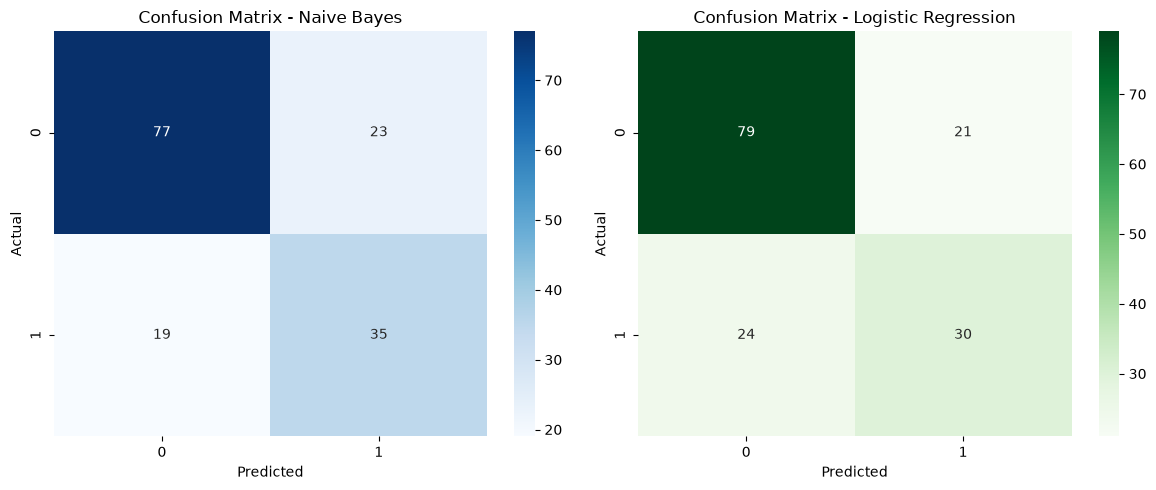

In [15]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix - Naive Bayes')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Confusion Matrix - Logistic Regression')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

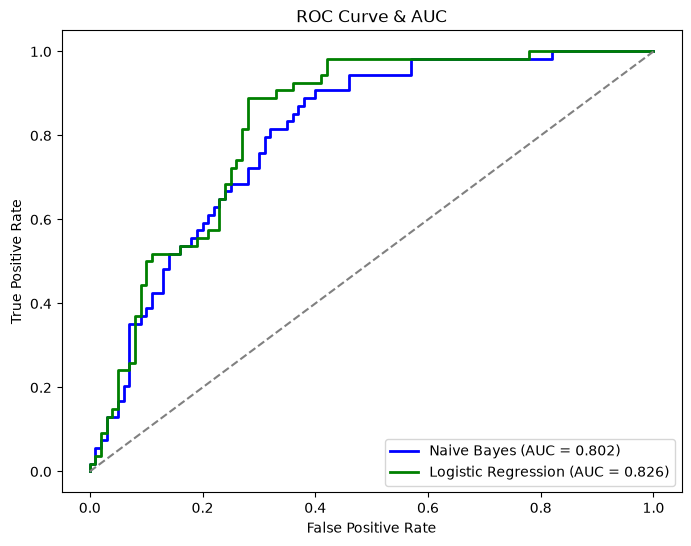

In [16]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_probs)
roc_auc_nb = auc(fpr_nb, tpr_nb)

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nb, tpr_nb, color='blue', lw=2, label=f'Naive Bayes (AUC = {roc_auc_nb:.3f})')
plt.plot(fpr_lr, tpr_lr, color='green', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve & AUC')
plt.legend(loc='lower right')
plt.show()

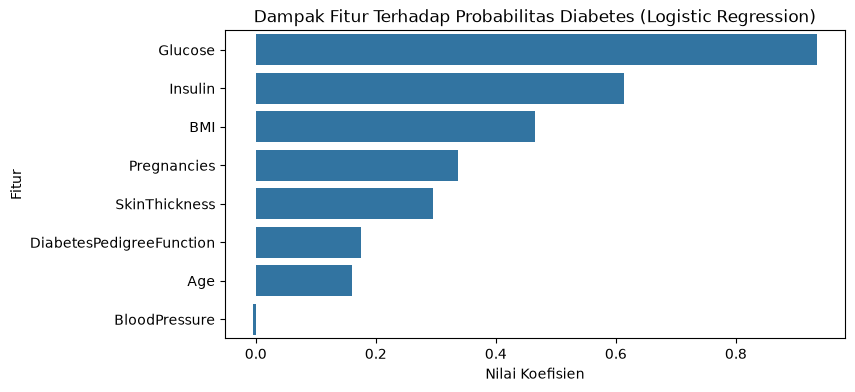

In [17]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
coefficients = pd.DataFrame({'Fitur': x.columns, 'Koefisien': lr_model.coef_[0]})
coefficients = coefficients.sort_values(by='Koefisien', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Koefisien', y='Fitur', data=coefficients)
plt.title('Dampak Fitur Terhadap Probabilitas Diabetes (Logistic Regression)')
plt.xlabel('Nilai Koefisien')
plt.ylabel('Fitur')
plt.show()

# 5. Analisis

Berdasarkan eksperimen dan hasil metrik evaluasi yang telah dilakukan, berikut adalah analisis perbandingan antara model Gaussian Naive Bayes (GNB) dan Logistic Regression (LR):

**1. Perbandingan Performa Berdasarkan Metrik**
* **Recall (Sensitivitas):** Gaussian Naive Bayes mengungguli Logistic Regression pada metrik *Recall* (GNB sekitar 0.64 berbanding LR sekitar 0.55). Dalam konteks diagnosis medis (diabetes), *Recall* seringkali menjadi metrik yang paling krusial karena kita ingin meminimalisir *False Negatives* (pasien yang sebenarnya diabetes tetapi diprediksi sehat). Oleh karena itu, secara bawaan (*out-of-the-box*), GNB lebih sensitif dalam mendeteksi kelas positif.
* **Accuracy dan F1-Score:** GNB juga menunjukkan performa *Accuracy* (~72%) dan *F1-Score* (~0.62) yang sedikit lebih tinggi dibandingkan LR pada pembagian data ini. 
* **AUC (Area Under ROC Curve):** Di sisi lain, Logistic Regression memiliki nilai AUC yang sedikit lebih tinggi (~0.82 berbanding ~0.80 milik GNB). Hal ini menunjukkan bahwa secara keseluruhan probabilitas yang dihasilkan oleh LR memiliki kemampuan separasi kelas (memisahkan mana yang diabetes dan tidak) yang sedikit lebih baik jika kita menyesuaikan *threshold* atau ambang batas keputusannya.

**2. Karakteristik dan Asumsi Model**
* Naive Bayes mengasumsikan bahwa seluruh fitur tidak saling bergantung (independen) satu sama lain. Meskipun asumsi ini sering kali dilanggar di dunia nyata (misal: BMI biasanya berkorelasi dengan ketebalan kulit), GNB tetap menunjukkan performa klasifikasi yang sangat baik dan cepat.
* Logistic Regression adalah model parametrik yang mencoba mencari hubungan linear antara fitur dan log-odds dari target. Berdasarkan visualisasi koefisien fitur, kita dapat melihat dengan jelas bahwa fitur **Glucose** adalah prediktor terkuat yang meningkatkan kemungkinan seseorang mengidap diabetes, disusul oleh **Insulin** dan **BMI**. Sebaliknya, fitur seperti *BloodPressure* memiliki koefisien negatif yang mendekati nol, menunjukkan dampak yang sangat minim atau terbalik terhadap prediksi.

# 6. Kesimpulan dan Saran

**Kesimpulan:**
Eksperimen ini menunjukkan bahwa klasifikasi pasien diabetes menggunakan *Pima Indians Diabetes Dataset* dapat dilakukan dengan cukup baik menggunakan model *Machine Learning* dasar. Fitur klinis seperti kadar Glukosa (*Glucose*), *Insulin*, Indeks Massa Tubuh (*BMI*), dan riwayat kehamilan (*Pregnancies*) merupakan faktor penentu utama dalam prediksi diabetes.

Dalam membandingkan kedua model, **Gaussian Naive Bayes** terbukti menjadi pilihan model dasar yang lebih aman jika tujuan utamanya adalah mengurangi risiko pasien diabetes yang tidak terdeteksi (memiliki *Recall* yang lebih tinggi). Sementara itu, **Logistic Regression** sangat berguna karena sifat interpretasinya yang sangat baik; kita bisa dengan mudah melihat fitur mana yang menaikkan atau menurunkan probabilitas diabetes melalui bobot koefisiennya.

**Saran dan Rekomendasi:**
Untuk eksperimen selanjutnya, beberapa langkah berikut dapat dilakukan untuk meningkatkan performa model:
1. **Penanganan Imbalanced Data:** Dataset ini didominasi oleh kelas Non-Diabetes (0). Kita bisa menerapkan teknik penyeimbangan data seperti *Oversampling* (contoh: SMOTE) pada kelas minoritas atau menggunakan parameter `class_weight='balanced'` pada Logistic Regression agar model tidak bias ke kelas mayoritas.
2. **Feature Selection:** Fitur dengan bobot yang sangat rendah (seperti *BloodPressure* pada model Logistic Regression) dapat coba dihapus (*drop*) pada eksperimen berikutnya. Mengurangi dimensi fitur yang tidak relevan dapat mengurangi kebisingan (*noise*) dan meningkatkan akurasi.
3. **Optimasi Threshold:** Karena Logistic Regression memiliki nilai AUC yang sangat baik, kita bisa mencari nilai *threshold* probabilitas yang optimal (bukan sekadar > 0.5) untuk secara manual meningkatkan nilai *Recall*-nya.